# 4. Attribution fidelity and calibrated uncertainty

This is the notebook the project exists for. Two questions:

1. **Is the explanation correct?** Scored against exact ground truth, and against two controls -- a uniform-random attribution, and the same method applied to an *untrained* model (the parameter-randomisation sanity check of Adebayo et al., 2018).
2. **Does the model know when it is wrong?** Interval coverage, sharpness, and a risk-coverage curve for abstention.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, torch
torch.set_num_threads(2)
pd.set_option("display.width", 200)
import matplotlib.pyplot as plt

# Notebooks run with cwd=notebooks/, so the figure and table roots have to be
# repointed at the repository's results/ tree. Without this every figure lands in
# notebooks/results/figures/ and the committed figures silently never update.
import saqa.viz as _viz, saqa.report as _report
_viz.FIGURES = ROOT / "results" / "figures"
_viz.TABLES = _report.TABLES = ROOT / "results" / "tables"
tables = _viz.TABLES
tables = pathlib.Path('../results/tables')
fid = pd.read_csv(tables / 'attribution_fidelity.csv') if (tables / 'attribution_fidelity.csv').exists() else None
cols = ['model', 'attribution', 'joint_precision', 'joint_recall',
        'joint_iou', 'joint_rank_corr', 'joint_top1_hit',
        'frame_localisation_error', 'n_joint_iou']
fid[[c for c in cols if c in fid.columns]].round(4) if fid is not None else 'run `make compare` first'

,model,attribution,joint_precision,joint_recall,joint_iou,joint_rank_corr,joint_top1_hit,frame_localisation_error
0,saqa_stgcn,integrated_gradients,0.5095,0.5095,0.4038,-0.2405,0.0000,0.0476
1,saqa_stgcn,occlusion,0.5282,0.5282,0.4256,-0.1738,0.0000,0.1163
2,saqa_stgcn,gradient,0.5275,0.5275,0.4181,-0.1060,0.0583,0.0505
3,saqa_stgcn,random,0.5551,0.5551,0.4442,0.0010,0.0333,0.0405
4,saqa_stgcn,integrated_gradients_untrained,0.6902,0.6902,0.5639,0.2699,0.4750,0.0561
5,saqa_stgcn,edge_importance_global,0.5267,0.5267,0.4098,-0.2249,0.0000,NaN
6,stgcn_dense,integrated_gradients,0.5431,0.5431,0.4233,-0.1764,0.0000,0.1108
7,stgcn_dense,occlusion,0.5493,0.5493,0.4413,-0.1452,0.0000,0.1458
8,stgcn_dense,gradient,0.5362,0.5362,0.4275,-0.0479,0.0333,0.0840
9,stgcn_dense,random,0.5551,0.5551,0.4442,0.0010,0.0333,0.0405


**How to read this.** The rows to compare against are `random` and `integrated_gradients_untrained`. An attribution method that does not beat both is not explaining the model -- it is reflecting the input statistics. Where that happens it is reported as a negative result.

F:\projects\new ai projects\skeletal-action-quality-attribution\results\figures\nb_attribution_fidelity.png


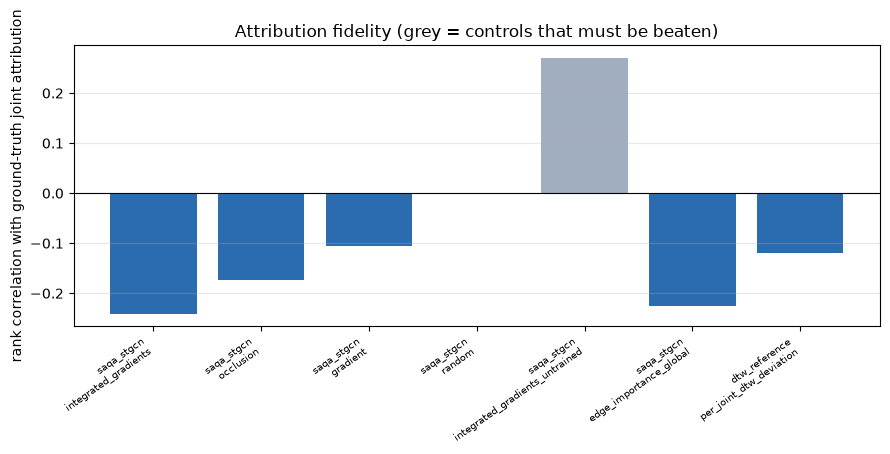

In [2]:
from saqa.viz import plot_attribution_fidelity
p = plot_attribution_fidelity('nb_attribution_fidelity.png')
print(p); plt.show()

## A single sequence, explained

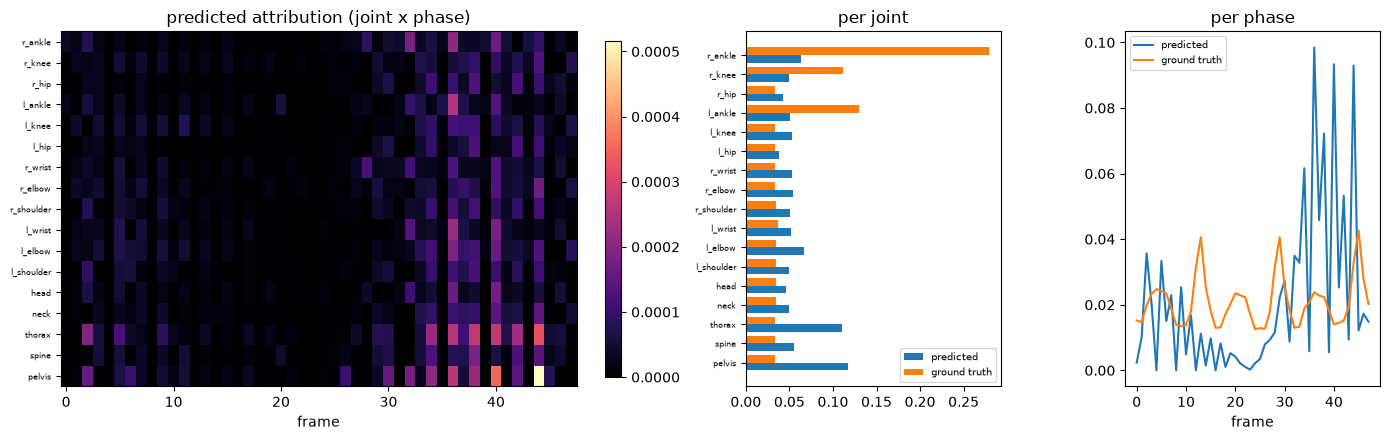

gait ['asymmetry', 'rom', 'jerk']


In [3]:
from saqa.config import load_config
from saqa.pipelines import make_splits, run_single, compute_attribution
from saqa.viz import plot_attribution_map
cfg = load_config('../configs/base.yaml', ['data.num_sequences=300', 'optim.epochs=4', 'run.out_dir=../results/runs_nb'])
sp = make_splits(cfg)
res = run_single(cfg, name='nb_attr', splits=sp, save=False, verbose=False)
k = int(np.argmax(sp.test.joint_truth.sum(1) > 0))
attr = compute_attribution(res.model, sp.test.coords[k:k+1], 'integrated_gradients', cfg)[0]
plot_attribution_map(attr, sp.test.joint_truth[k], sp.test.frame_truth[k],
                     name='nb_attribution_map.png'); plt.show()
print(sp.test.samples[k].action, [d.kind for d in sp.test.samples[k].degradations])

## Monotonicity: does adding a defect ever *raise* the score?

The ordinal head guarantees rank consistency (its survival function cannot cross itself), but it does **not** guarantee monotonicity in the input. That is an empirical question and it is measured, not claimed.

In [4]:
from saqa.pipelines import monotonicity_check, ordinal_consistency
rep, ladders, preds = monotonicity_check(res.model, cfg, num_ladders=24)
print({k: round(v, 4) for k, v in rep.items() if not k.startswith('n__')})
print(ordinal_consistency(res.model, sp.test))

{'violation_rate': 0.4417, 'ladders_with_any_violation': 0.5417, 'max_increase': np.float64(0.002), 'n_ladders': 24.0, 'violation_rate__asymmetry': 0.0, 'violation_rate__compensation': 0.4, 'violation_rate__instability': 0.375, 'violation_rate__jerk': 0.75, 'violation_rate__rom': 0.525, 'violation_rate__tempo': 0.6}


{'rank_inconsistency': 0.0, 'n': 76.0}


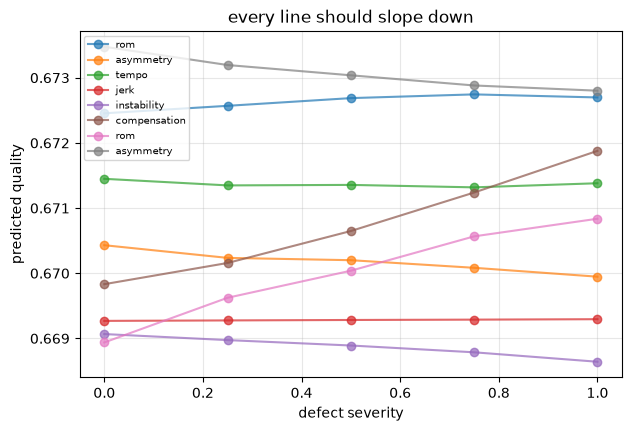

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for lad, pr in list(zip(ladders, preds))[:8]:
    ax.plot(lad['severity'], pr, 'o-', alpha=0.7, label=lad['kind'])
ax.set_xlabel('defect severity'); ax.set_ylabel('predicted quality')
ax.set_title('every line should slope down'); ax.grid(alpha=0.3)
ax.legend(fontsize=7); plt.show()

## Intervals: coverage next to sharpness

Coverage alone cannot distinguish a useful interval from a constant-width one, so the width conditional on the model being wrong is reported alongside. A ratio above 1 means the interval widens where it should.

In [6]:
p = tables / 'uncertainty.csv'
pd.read_csv(p).round(4) if p.exists() else 'run `make compare` first'

,method,coverage,nominal,coverage_gap,mean_width,median_width,crossing_rate,width_ratio_wrong_right,aurc,aurc_oracle,e_aurc,error_auroc
0,saqa_stgcn,0.896,0.9,-0.004,0.6021,0.6119,0.0,1.0143,0.1422,0.0680,0.0742,0.5347
1,stgcn_dense,0.860,0.9,-0.040,0.6309,0.6320,0.0,0.9995,0.1488,0.0704,0.0784,0.5086
2,tcn,0.864,0.9,-0.036,0.5768,0.5589,0.0,1.0146,0.1438,0.0726,0.0712,0.5491
3,lstm,0.800,0.9,-0.100,0.6037,0.5978,0.0,1.0090,0.1556,0.0742,0.0814,0.4985
4,frame_average,0.932,0.9,0.032,0.5999,0.5999,0.0,0.9977,0.1602,0.0717,0.0885,0.4971
5,untrained_stgcn,1.000,0.9,0.100,1.4094,1.4094,0.0,1.0001,0.4396,0.2629,0.1768,0.5552
6,kinematic_gbr,0.880,0.9,-0.020,0.5693,0.5981,0.0,1.0107,0.1252,0.0571,0.0681,0.5398
7,dtw_reference,0.864,0.9,-0.036,0.5396,0.5396,0.0,1.0000,0.1485,0.0633,0.0852,0.4744
8,framewise_reference,0.868,0.9,-0.032,0.5703,0.5703,0.0,1.0000,0.1511,0.0641,0.0870,0.5193


F:\projects\new ai projects\skeletal-action-quality-attribution\results\figures\nb_risk_coverage.png


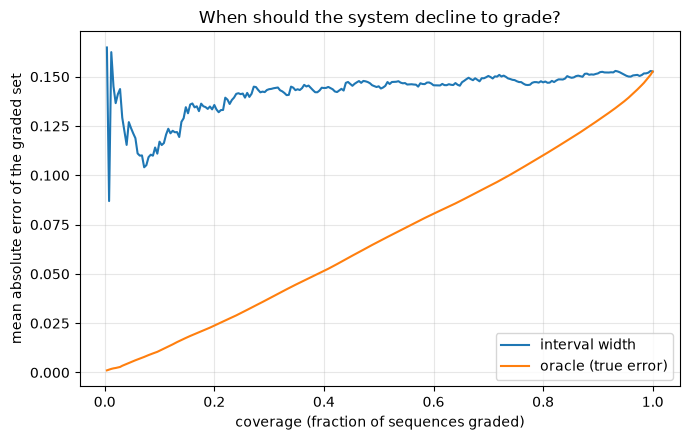

In [7]:
from saqa.viz import plot_risk_coverage
p = plot_risk_coverage('../results/runs/saqa_stgcn/per_item.csv',
                       name='nb_risk_coverage.png')
print(p); plt.show() if p else print('run `make compare` first')